In [1]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [2]:
''' 
This notebook performs prices forecasting using past observations: 
        Historical data is split into training (2014-2023) and test (2024) periods (done)
        A sARIMAX(p,d,q) is trained on the returns timeseries (done)
        Model results scored and recored (done)
        Forecast is plotted against true observations (done)

'''

' \nThis notebook performs prices forecasting using past observations: \n        Historical data is split into training (2014-2023) and test (2024) periods (done)\n        A sARIMAX(p,d,q) is trained on the returns timeseries (done)\n        Model results scored and recored (done)\n        Forecast is plotted against true observations (done)\n\n'

In [3]:
# load prices.csv
prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)

print(prices.info())
prices

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2735 entries, 2014-01-01 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2735 non-null   float64
 1   CAD=X     2735 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-01,1.06193,1.374495
2014-01-02,1.06445,1.376671
2014-01-03,1.06691,1.366662
2014-01-06,1.06305,1.359601
2014-01-07,1.06609,1.363196
...,...,...
2024-06-24,1.37013,1.068776
2024-06-25,1.36579,1.073272
2024-06-26,1.36611,1.070962


In [4]:
forecast_name = 'price' 
data = prices.copy()

In [5]:
tickers = data.columns
tickers

Index(['EURUSD=X', 'CAD=X'], dtype='object')

In [6]:
# Split data into train, and test sets 
train_split = '2023-01-01' 

train = data.loc[:'2022-12-31'] 
test = data.loc[train_split:]

# check
print(train.shape, test.shape)
print(train.index.min(), train.index.max()) 
print(test.index.min(), test.index.max())

print("Train")
print(train) 
print("Test")
print(test)

(2345, 2) (390, 2)
2014-01-01 00:00:00 2022-12-30 00:00:00
2023-01-02 00:00:00 2024-06-28 00:00:00
Train
            EURUSD=X     CAD=X
Date                          
2014-01-01   1.06193  1.374495
2014-01-02   1.06445  1.376671
2014-01-03   1.06691  1.366662
2014-01-06   1.06305  1.359601
2014-01-07   1.06609  1.363196
...              ...       ...
2022-12-26   1.35897  1.066780
2022-12-27   1.35570  1.064022
2022-12-28   1.35250  1.063717
2022-12-29   1.35994  1.062925
2022-12-30   1.35520  1.066075

[2345 rows x 2 columns]
Test
            EURUSD=X     CAD=X
Date                          
2023-01-02   1.35281  1.070973
2023-01-03   1.35590  1.067771
2023-01-04   1.36741  1.054685
2023-01-05   1.34851  1.060637
2023-01-06   1.35599  1.052222
...              ...       ...
2024-06-24   1.37013  1.068776
2024-06-25   1.36579  1.073272
2024-06-26   1.36611  1.070962
2024-06-27   1.37045  1.068011
2024-06-28   1.36993  1.070847

[390 rows x 2 columns]


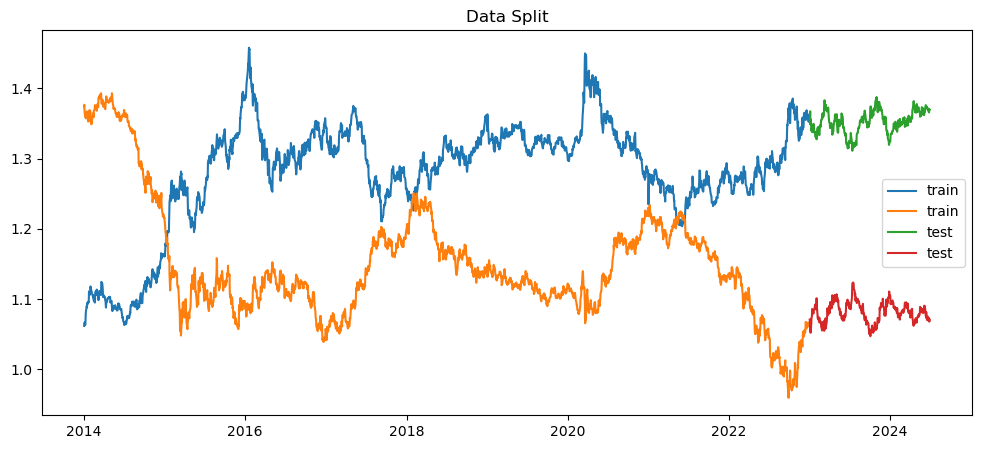

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="train") 
plt.plot(test.index, test, label="test")

plt.title("Data Split")
plt.legend()
plt.show()

In [8]:
# A first model
model_dict = {}
p, d, q = (1, 0, 1) # p, d, q
for ticker in tickers:
    # sARIMAX(p,d,q,s)
    model = SARIMAX( train[ticker], 
                        order=(p,d,q),
                        # trend='ct',
                        # time_varying_regression=True,
                        )
    # fit model
    model_history = model.fit()
    model_dict[ticker] = model_history

    print(f'\n  {ticker} \n')
    print(f'\n     sARIMAX({p},{d},{q}) Summary: \n')
    print(model_history.summary())


  EURUSD=X 


     sARIMAX(1,0,1) Summary: 

                               SARIMAX Results                                
Dep. Variable:               EURUSD=X   No. Observations:                 2345
Model:               SARIMAX(1, 0, 1)   Log Likelihood                8604.611
Date:                Sun, 15 Mar 2026   AIC                         -17203.222
Time:                        23:29:28   BIC                         -17185.942
Sample:                             0   HQIC                        -17196.929
                               - 2345                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   7.15e-05    1.4e+04      0.000       1.000       1.000
ma.L1         -0.0101      0.014     -0.708      0.479      -0.038       0.018
sigma2

In [16]:
# Single 1-step ahead forecast
preds = pd.DataFrame(index=test.index, columns=tickers)

for ticker in tickers:
    print(ticker) 
    model_results = model_dict[ticker]

    # 1-step variance forecast
    pred = model_results.forecast(steps=1)  

    print(f'Date: {test.index[0]}')    
    print(f'    Actual Prices 1-step ahead:     {test[ticker].iloc[0]:.4f}') 
    print(f'    Predicted Prices 1-step ahead:  {float(pred.iloc[0])}') 

EURUSD=X
Date: 2023-01-02 00:00:00
    Actual Prices 1-step ahead:     1.3528
    Predicted Prices 1-step ahead:  1.3552301289781372
CAD=X
Date: 2023-01-02 00:00:00
    Actual Prices 1-step ahead:     1.0710
    Predicted Prices 1-step ahead:  1.065885295673271


In [22]:
print(tickers)

Index(['EURUSD=X', 'CAD=X'], dtype='object')


In [ ]:
# Rolling forecast 1-step ahead 
preds = pd.DataFrame(index=test.index, columns=tickers)

window_size = 1

time_spent = {}
for ticker in tickers: 
    preds_list = [] 

    history = train[ticker].copy()

    model_results = model_dict[ticker]
    
    start = time.time()
    for i, h in enumerate(test.index): 
        if i % window_size == 0:
            model = SARIMAX(history, 
                    order=(p,d,q),
                    # trend='ct',
                    # time_varying_regression=True,
                    )
            model_results = model.fit(disp='off')
            
        # 1-step ahead forecast 
        pred = model_results.forecast(steps=1)
        
        # add to predictions
        preds_list.append(float(pred.iloc[0]))  

        # update history
        history.loc[h] = test[ticker].loc[h] 
        
    preds[ticker] = preds_list
    end = time.time() 
    time_spent[ticker] = end - start

print(time_spent)
preds

{'EURUSD=X': 558.8036208152771, 'CAD=X': 202.41576313972473}


,EURUSD=X,CAD=X
Date,,
2023-01-02,1.355230,1.065885
2023-01-03,1.352817,1.070757
2023-01-04,1.355852,1.067682
2023-01-05,1.367282,1.054747
2023-01-06,1.348722,1.060401
...,...,...
2024-06-24,1.368471,1.070612
2024-06-25,1.370099,1.068693
2024-06-26,1.365813,1.073057


In [41]:
# evaluate model
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scores = {}
for ticker in tickers:   
    
    rootmeansquarederr = rmse(test[ticker], preds[ticker])
    sMAPE = smape(test[ticker], preds[ticker]) 

    scores[ticker] = {'RMSE': rootmeansquarederr, 'sMAPE': sMAPE} 

scores

{'EURUSD=X': {'RMSE': np.float64(0.004720780524582319),
  'sMAPE': np.float64(0.2655452750973684)},
 'CAD=X': {'RMSE': np.float64(0.004690185608188517),
  'sMAPE': np.float64(0.3314697612013006)}}

In [42]:
# scores to data
scores_df = pd.DataFrame.from_dict(scores, orient='index') 

# save scores
scores_df.to_csv(f'../results/tables/sarima101_scores.csv')

scores_df

,RMSE,sMAPE
EURUSD=X,0.004721,0.265545
CAD=X,0.004690,0.331470


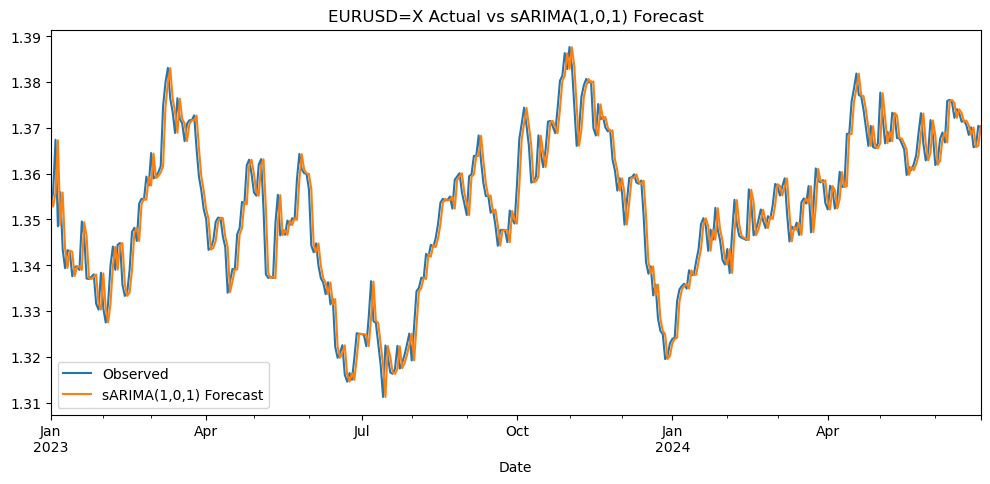

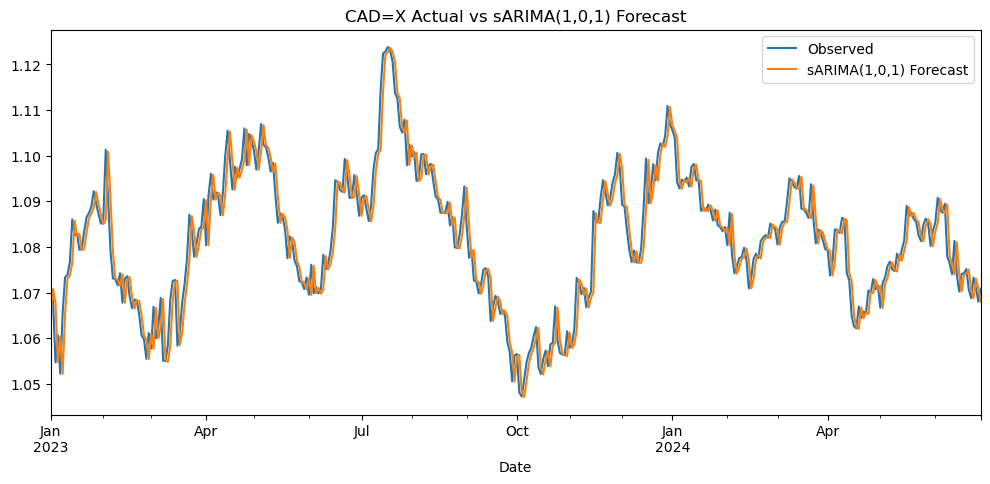

In [43]:
for ticker in tickers:
    plt.figure(figsize=(12, 5))
    
    title = f"{ticker} Actual vs sARIMA({p},{d},{q}) Forecast"

    test[ticker].plot(label="Observed")
    preds[ticker].plot(label=f"sARIMA({p},{d},{q}) Forecast")
    
    plt.title(title)

    # save plot 
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.legend()
    plt.show()

In [44]:
results = preds.copy()

new_columns = [] 
for ticker in tickers:
    new_columns.append(f'{ticker}_forecast')

results.columns = new_columns

print(results.info())
results

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EURUSD=X_forecast  390 non-null    float64
 1   CAD=X_forecast     390 non-null    float64
dtypes: float64(2)
memory usage: 17.2 KB
None


,EURUSD=X_forecast,CAD=X_forecast
Date,,
2023-01-02,1.355230,1.065885
2023-01-03,1.352817,1.070757
2023-01-04,1.355852,1.067682
2023-01-05,1.367282,1.054747
2023-01-06,1.348722,1.060401
...,...,...
2024-06-24,1.368471,1.070612
2024-06-25,1.370099,1.068693
2024-06-26,1.365813,1.073057


In [45]:
# save results
results.to_csv(f"../results/forecasts/sARIMA101_forecasts.csv")